# Dimensionality Reduction (PCA)
Steel Industry Energy Consumption


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

### 1. Load engineered dataset 

In [ ]:
df = pd.read_csv("Steel_energy_consumption_engineered.csv")

df = df.drop(columns=["date", "High_Load","Day_of_week", "Weekend"])   
X = df.drop("Usage_kWh", axis=1)
y = df["Usage_kWh"]

categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric_columns = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_columns)
print("Numeric:", numeric_columns)

Categorical: ['WeekStatus', 'Day_of_week', 'Load_Type', 'Day_of_Week', 'Month', 'Weekend']
Numeric: ['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Hour', 'Power_Factor_Ratio']


## 2. Same train-test split as Week 2

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

## 3. Encode + scale — fit on training set only
For PCA we also need the numeric columns **scaled**, so this step one-hot
encodes the categoricals and standard-scales the numeric columns, fitting only on
`X_train` (no data leakage).

In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numeric_columns),
    ]
)

X_train_enc = preprocessor.fit_transform(X_train)   # fit on train only
X_test_enc = preprocessor.transform(X_test)          # reuse train's fit

feature_names = preprocessor.get_feature_names_out()
n_features = X_train_enc.shape[1]
print("Encoded feature count:", n_features)

Encoded feature count: 41


### 4. Fit PCA with n_components = total number of encoded features

In [87]:
pca_full = PCA(n_components=n_features, random_state=RANDOM_STATE)
X_train_pca_full = pca_full.fit_transform(X_train_enc)   # fit on train only
X_test_pca_full = pca_full.transform(X_test_enc)

explained_var = pca_full.explained_variance_ratio_

### 5. Scree plot

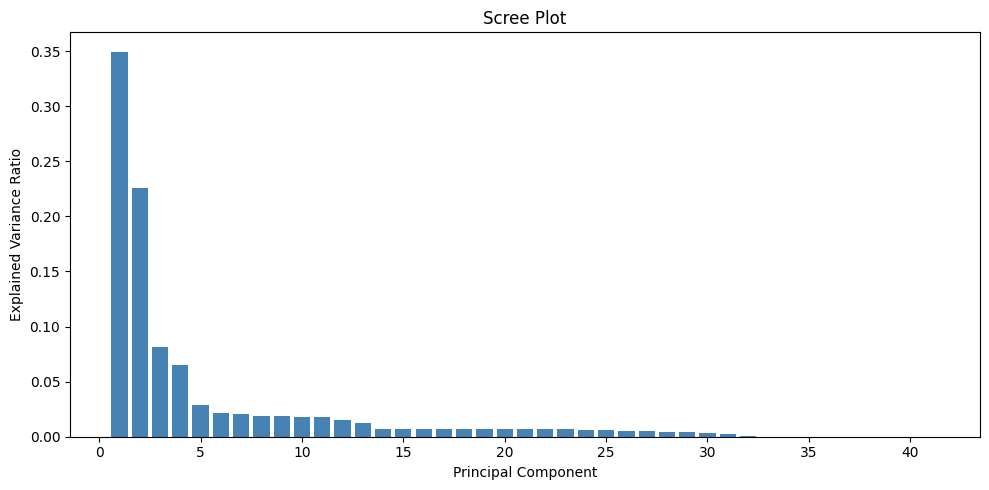

In [88]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, n_features + 1), explained_var, color="steelblue")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.tight_layout()
plt.savefig("scree_plot.png", dpi=150)
plt.show()

## 6. Cumulative explained variance curve (95% threshold)

Components needed for 95% variance: 22


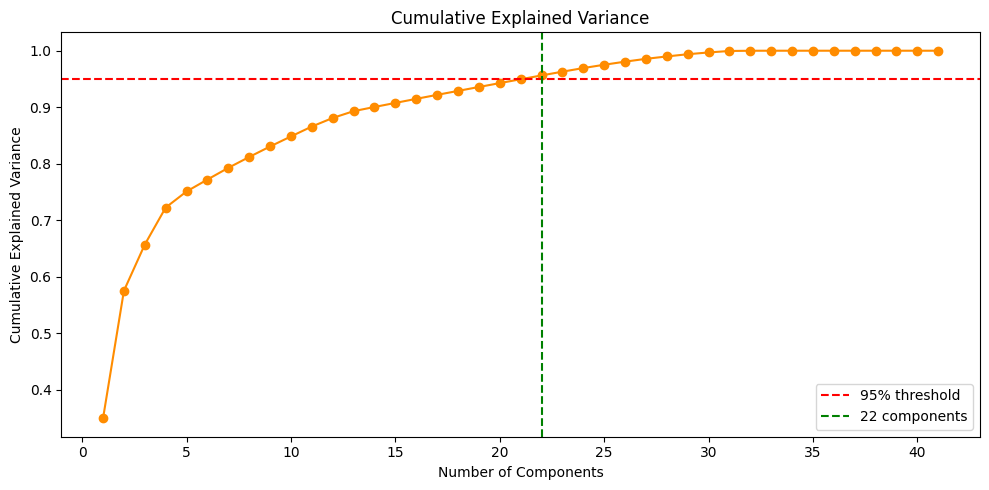

In [ ]:
cumulative_var = np.cumsum(explained_var)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_features + 1), cumulative_var, marker="o", color="darkorange")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
plt.axvline(x=n_components_95, color="green", linestyle="--",
            label=f"{n_components_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.savefig("cumulative_variance.png", dpi=150)
plt.show()

## 7. Retrain Random Forest — three versions

In [90]:
def evaluate(model, X_tr, y_tr, X_te, y_te, label):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    print(f"{label:30s} MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
    return {"Model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

# (a) Original encoded features (Week 2 baseline, retrained here for a fair comparison)
rf_original = RandomForestRegressor(random_state=RANDOM_STATE)
result_original = evaluate(rf_original, X_train_enc, y_train, X_test_enc, y_test,
                            "Original features")

# (b) 3 PCA components
X_train_pca3, X_test_pca3 = X_train_pca_full[:, :3], X_test_pca_full[:, :3]
rf_pca3 = RandomForestRegressor(random_state=RANDOM_STATE)
result_pca3 = evaluate(rf_pca3, X_train_pca3, y_train, X_test_pca3, y_test,
                        "3-component PCA")

# (c) Components for 95% variance
X_train_pca95 = X_train_pca_full[:, :n_components_95]
X_test_pca95 = X_test_pca_full[:, :n_components_95]
rf_pca95 = RandomForestRegressor(random_state=RANDOM_STATE)
result_pca95 = evaluate(rf_pca95, X_train_pca95, y_train, X_test_pca95, y_test,
                         f"{n_components_95}-component PCA (95%)")

Original features              MAE=0.3634  RMSE=1.0722  R2=0.9990
3-component PCA                MAE=1.3009  RMSE=2.6464  R2=0.9938
22-component PCA (95%)         MAE=1.3060  RMSE=2.6570  R2=0.9938


## 8. Compare RMSE and R² across the three versions

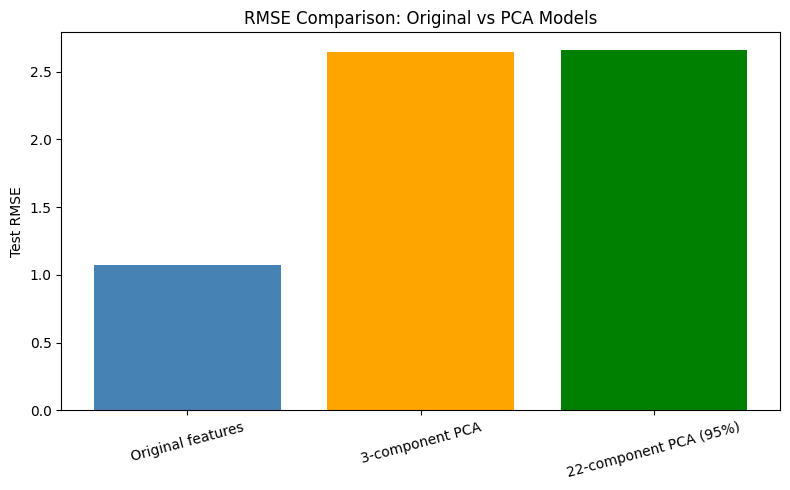

,Model,MAE,RMSE,R2
0,Original features,0.363393,1.072233,0.998989
1,3-component PCA,1.300894,2.646352,0.993839
2,22-component PCA (95%),1.306014,2.657049,0.993789


In [91]:
comparison = pd.DataFrame([result_original, result_pca3, result_pca95])
comparison

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["RMSE"], color=["steelblue", "orange", "green"])
plt.ylabel("Test RMSE")
plt.title("RMSE Comparison: Original vs PCA Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("rmse_comparison.png", dpi=150)
plt.show()

comparison

## 9. Loading heatmap — original (encoded) features vs PC1-PC3

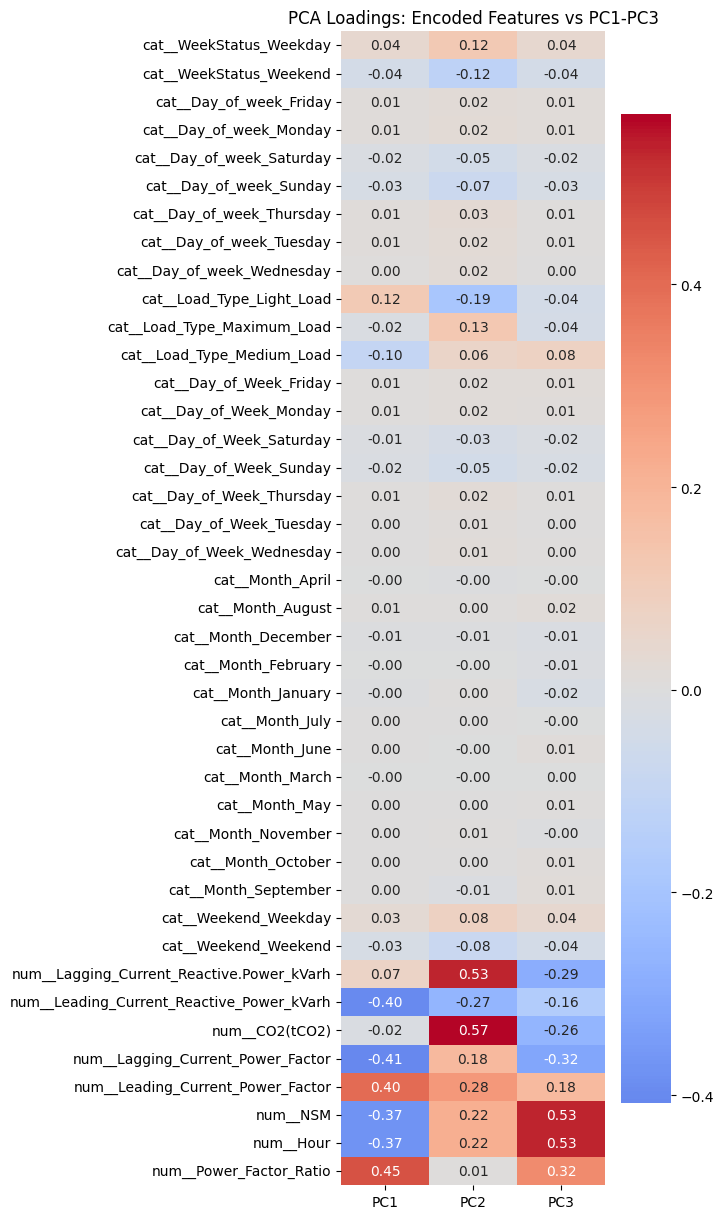

In [92]:
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    index=feature_names,
    columns=["PC1", "PC2", "PC3"]
)

plt.figure(figsize=(7, max(6, len(feature_names) * 0.3)))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("PCA Loadings: Encoded Features vs PC1-PC3")
plt.tight_layout()
plt.savefig("pca_loadings_heatmap.png", dpi=150)
plt.show()

## 10. Dimensionality Reduction Report

**Results from this run:**

| Version | MAE | RMSE | R2 |
|---|---|---|---|
| Original features (41 encoded) | 0.36 | 1.08 | 0.9990 |
| 3-component PCA | 1.30 | 2.64 | 0.9938 |
| 22-component PCA (95% variance) | 1.31 | 2.66 | 0.9938 |

- **Did accuracy drop significantly?** Not drastically in absolute terms, but relatively yes:
  RMSE roughly doubles from 1.08 to ~2.65 when moving from the original 41 encoded features to
  either PCA version, and R² drops from 0.999 to 0.994. For a task where every kWh of error
  matters, that's a real cost, even though 0.994 is still a strong R².
- **How many features can safely be removed?** Of the 41 one-hot/numeric encoded features,
  only 22 are needed to retain 95% of variance — meaning about half the encoded feature space
  (largely redundant one-hot categories and correlated power/current readings) can be dropped
  without losing much signal. Interestingly, going all the way down to just 3 components loses
  almost the same amount of accuracy as 22 components — most of the useful signal is packed
  into the first few components.
- **Would you recommend PCA for a memory-constrained device?** For this dataset, only
  conditionally. Random Forest already runs efficiently on the original 41 features, and the
  accuracy drop from PCA (R² 0.999 → 0.994) is non-trivial for an energy-monitoring use case.
  PCA would be worth it if the deployment target genuinely cannot hold 41 input features in
  memory or needs faster inference — the 3-component version gets you almost all of PCA's
  benefit with minimal added complexity over the 22-component version. Otherwise, the original
  feature set is the better choice here.

## 11. Save the final pipeline

We ship the **original-feature** Random Forest (encoder + scaler + model, no PCA) since it's
the most accurate and keeps the prediction form simple — users enter real feature values, not
abstract PCA numbers.

In [93]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_original)
])

# refit on the full training data already done above via rf_original.fit(X_train_enc, y_train)
# but Pipeline needs to see raw X_train (before manual preprocessor.fit_transform), so refit cleanly:
final_pipeline.fit(X_train, y_train)

joblib.dump(final_pipeline, "model.joblib", compress=3)  # compress: RF with many trees can get large
print("Saved model.joblib")

Saved model.joblib
